In [1]:
##Загрузка данных
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

df = pd.read_excel("Тестовое задание, аналитик ВВ.xlsx")

df.head()


,Дата заказа,Курьер,ДаркСтор,Номер заказа,Час заказа,Заказ просрочен по регламентному времени сборки,Заказ просрочен по общему регламентному времени заказа,Фактическое время исполнения заказа,Регламентное время на весь заказ
0,Дата 1,Курьер 1,Склад 1,1,16,0,0,4.950167,15
1,Дата 1,Курьер 2,Склад 1,2,13,0,0,5.822283,15
2,Дата 1,Курьер 2,Склад 1,4,10,0,0,7.261667,15
3,Дата 1,Курьер 6,Склад 1,8,18,0,0,8.196333,15
4,Дата 1,Курьер 8,Склад 1,10,10,0,0,8.911167,15


In [2]:
##Сохранение DataFrame в таблицу SQL ради удобства
conn = sqlite3.connect("orders.db")

df.to_sql("orders", conn, if_exists="replace", index=False)

197422

##1.ПЕРВИЧНЫЙ АНАЛИЗ

In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197422 entries, 0 to 197421
Data columns (total 9 columns):
 #   Column                                                  Non-Null Count   Dtype  
---  ------                                                  --------------   -----  
 0   Дата заказа                                             197422 non-null  object 
 1   Курьер                                                  197422 non-null  object 
 2   ДаркСтор                                                197422 non-null  object 
 3   Номер заказа                                            197422 non-null  int64  
 4   Час заказа                                              197422 non-null  int64  
 5   Заказ просрочен по регламентному времени сборки         197422 non-null  int64  
 6   Заказ просрочен по общему регламентному времени заказа  197422 non-null  int64  
 7   Фактическое время исполнения заказа                     197422 non-null  float64
 8   Регламентное время на вес

В датасете 197 422 заказа за 7 дней, пропущенных значений нет,т.е данные достаточно чистые и готовы к работе

In [4]:
df.describe()

,Номер заказа,Час заказа,Заказ просрочен по регламентному времени сборки,Заказ просрочен по общему регламентному времени заказа,Фактическое время исполнения заказа,Регламентное время на весь заказ
count,197422.000000,197422.000000,197422.000000,197422.000000,197422.000000,197422.000000
mean,98711.500000,13.541262,0.043622,0.114769,45.754922,66.064699
std,56990.966759,5.294625,0.204254,0.318744,33.038791,38.310800
min,1.000000,0.000000,0.000000,0.000000,0.501000,15.000000
25%,49356.250000,10.000000,0.000000,0.000000,25.496117,30.000000
50%,98711.500000,14.000000,0.000000,0.000000,38.696642,60.000000
75%,148066.750000,18.000000,0.000000,0.000000,54.621442,60.000000
max,197422.000000,23.000000,1.000000,1.000000,769.667500,360.000000


Базовая статистика, сразу видим диапозон времени доставки заказа  и средние значения. 
среднее фактическое время доставки - 45.7 минут
средний регламент доставки - 66 минут
То есть,среднем доставка происходит быстрее регламента. Однако, макксимальное фактисеское время достигает 769 минут,что говорит о возможных редких экстремальных задержек


In [5]:
df.nunique()


Дата заказа                                                    7
Курьер                                                      1193
ДаркСтор                                                      18
Номер заказа                                              197422
Час заказа                                                    24
Заказ просрочен по регламентному времени сборки                2
Заказ просрочен по общему регламентному времени заказа         2
Фактическое время исполнения заказа                       182230
Регламентное время на весь заказ                              13
dtype: int64

Видим количество уникальных заказов, курьеров и даркСторов. Также косвенно можем увидеть и диапозон заказов:
197 422 уникальных заказа
1193 курьера
18 дарксторов
7 дней



##2.ОБЩАЯ СТАТИСТИКА


In [6]:
##Доля просроченных заказов
query = """
SELECT
AVG("Заказ просрочен по общему регламентному времени заказа") as late_rate
FROM orders
"""

pd.read_sql(query, conn)

,late_rate
0,0.114769


Видим качество доставки: Около 11.5% заказов доставляются с опозданием относительно регламента, т.е примерно каждый девятый заказ доставляется с опозданием



In [7]:
##Просрочка сборки
query = """
SELECT
AVG("Заказ просрочен по регламентному времени сборки") as assembly_late_rate
FROM orders
"""

pd.read_sql(query, conn)


,assembly_late_rate
0,0.043622


Просрочка сборки составляет около 4.4% заказов, что значительно ниже общей просрочки доставки.Видимо,что основные задержки происходят  не на этапе сборки, а во время доставки

In [8]:
##Среднее время доставки
query = """
SELECT
AVG("Фактическое время исполнения заказа") as avg_delivery,
AVG("Регламентное время на весь заказ") as avg_regulation
FROM orders
"""

pd.read_sql(query, conn)

,avg_delivery,avg_regulation
0,45.754922,66.064699


Среднее фактическое время доставки значительно ниже регламентного.

##3.АНАЛИЗ ЗАКАЗОВ ПО ЧАСАМ

In [9]:
##Количество заказов по часам

query = """
SELECT
"Час заказа",
COUNT(*) as orders
FROM orders
GROUP BY "Час заказа"
ORDER BY "Час заказа"
"""

orders_by_hour = pd.read_sql(query, conn)
orders_by_hour

,Час заказа,orders
0,0,4679
1,1,2115
2,2,1108
3,3,858
4,4,758
5,5,1225
6,6,3416
7,7,6534
8,8,11086
9,9,13880


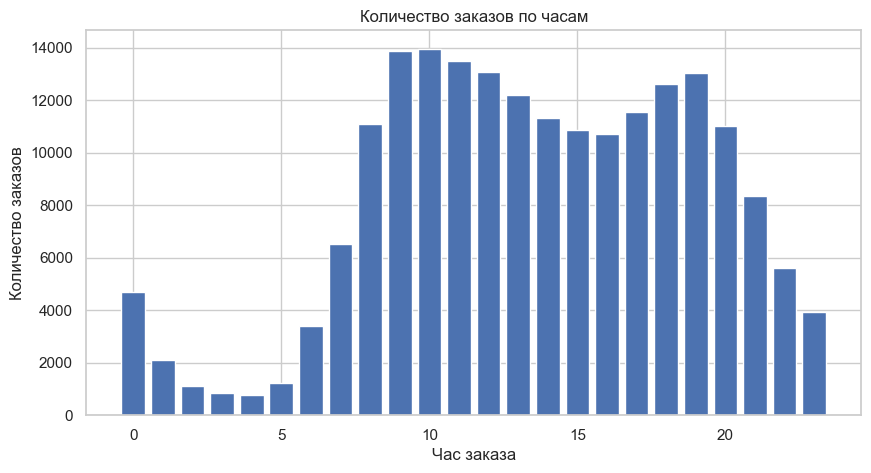

In [10]:
plt.figure(figsize=(10,5))

plt.bar(orders_by_hour["Час заказа"], orders_by_hour["orders"])

plt.title("Количество заказов по часам")
plt.xlabel("Час заказа")
plt.ylabel("Количество заказов")

plt.show()

По графику можно увидеть: 
минимальное количество заказов ночью(2-5),дальше рост заказов утром,затем пик заказов с 9 до 12 и второй пик веером(18-20).


In [11]:
##Просрочка по часам
query = """
SELECT
"Час заказа",
AVG("Заказ просрочен по общему регламентному времени заказа") as late_rate
FROM orders
GROUP BY "Час заказа"
ORDER BY "Час заказа"
"""

late_by_hour = pd.read_sql(query, conn)
late_by_hour

,Час заказа,late_rate
0,0,0.089335
1,1,0.088889
2,2,0.068592
3,3,0.068765
4,4,0.071240
5,5,0.099592
6,6,0.119731
7,7,0.116009
8,8,0.095887
9,9,0.086239


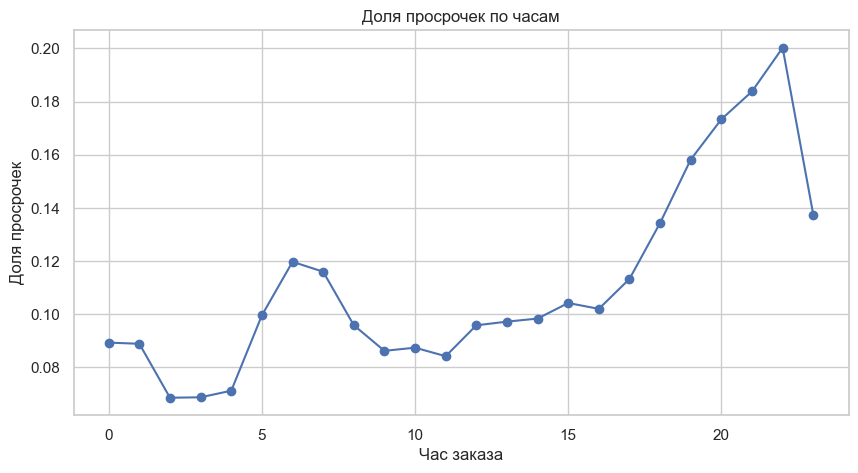

In [12]:
plt.figure(figsize=(10,5))

plt.plot(late_by_hour["Час заказа"], late_by_hour["late_rate"], marker="o")

plt.title("Доля просрочек по часам")
plt.xlabel("Час заказа")
plt.ylabel("Доля просрочек")

plt.show()

Минимальная доля просрочек наблюдается ночью и ранним утром (примерно 2–5 часов), где она составляет около 6–7%, что логичеки связано с низким количеством заказов
Начиная примерно с 17–18 часов доля просрочек начинает заметно расти,что совпадает с пиковым количеством заказов,т.е вечером возникает сильная нагрузка на доставку.
Это может быть связанно с недостаточным количеством курьеров и перегрузкой отдельных складов.
После 22 часов доля просрочек снова снижается.

Возможные пути решения,требующие дополнительного анализа:
yвеличения числа курьеров в часы пик,
перераспределения заказов между складами


##3.АНАЛИЗ ПО СКЛАДАМ


In [13]:
query = """
SELECT
"ДаркСтор",
COUNT(*) as orders,
AVG("Заказ просрочен по общему регламентному времени заказа") as late_rate,
AVG("Фактическое время исполнения заказа") as avg_delivery
FROM orders
GROUP BY "ДаркСтор"
ORDER BY late_rate DESC
"""

store_stats = pd.read_sql(query, conn)
store_stats

,ДаркСтор,orders,late_rate,avg_delivery
0,Склад 6,8156,0.189063,61.058311
1,Склад 8,8182,0.185040,55.149962
2,Склад 3,5503,0.169907,59.384338
3,Склад 10,9069,0.166832,47.365186
4,Склад 2,15896,0.147081,41.072904
5,Склад 5,25010,0.146981,40.092935
6,Склад 7,5204,0.141045,54.442852
7,Склад 15,8875,0.107268,34.935783
8,Склад 16,8917,0.103622,46.933318
9,Склад 17,12277,0.101083,44.268995


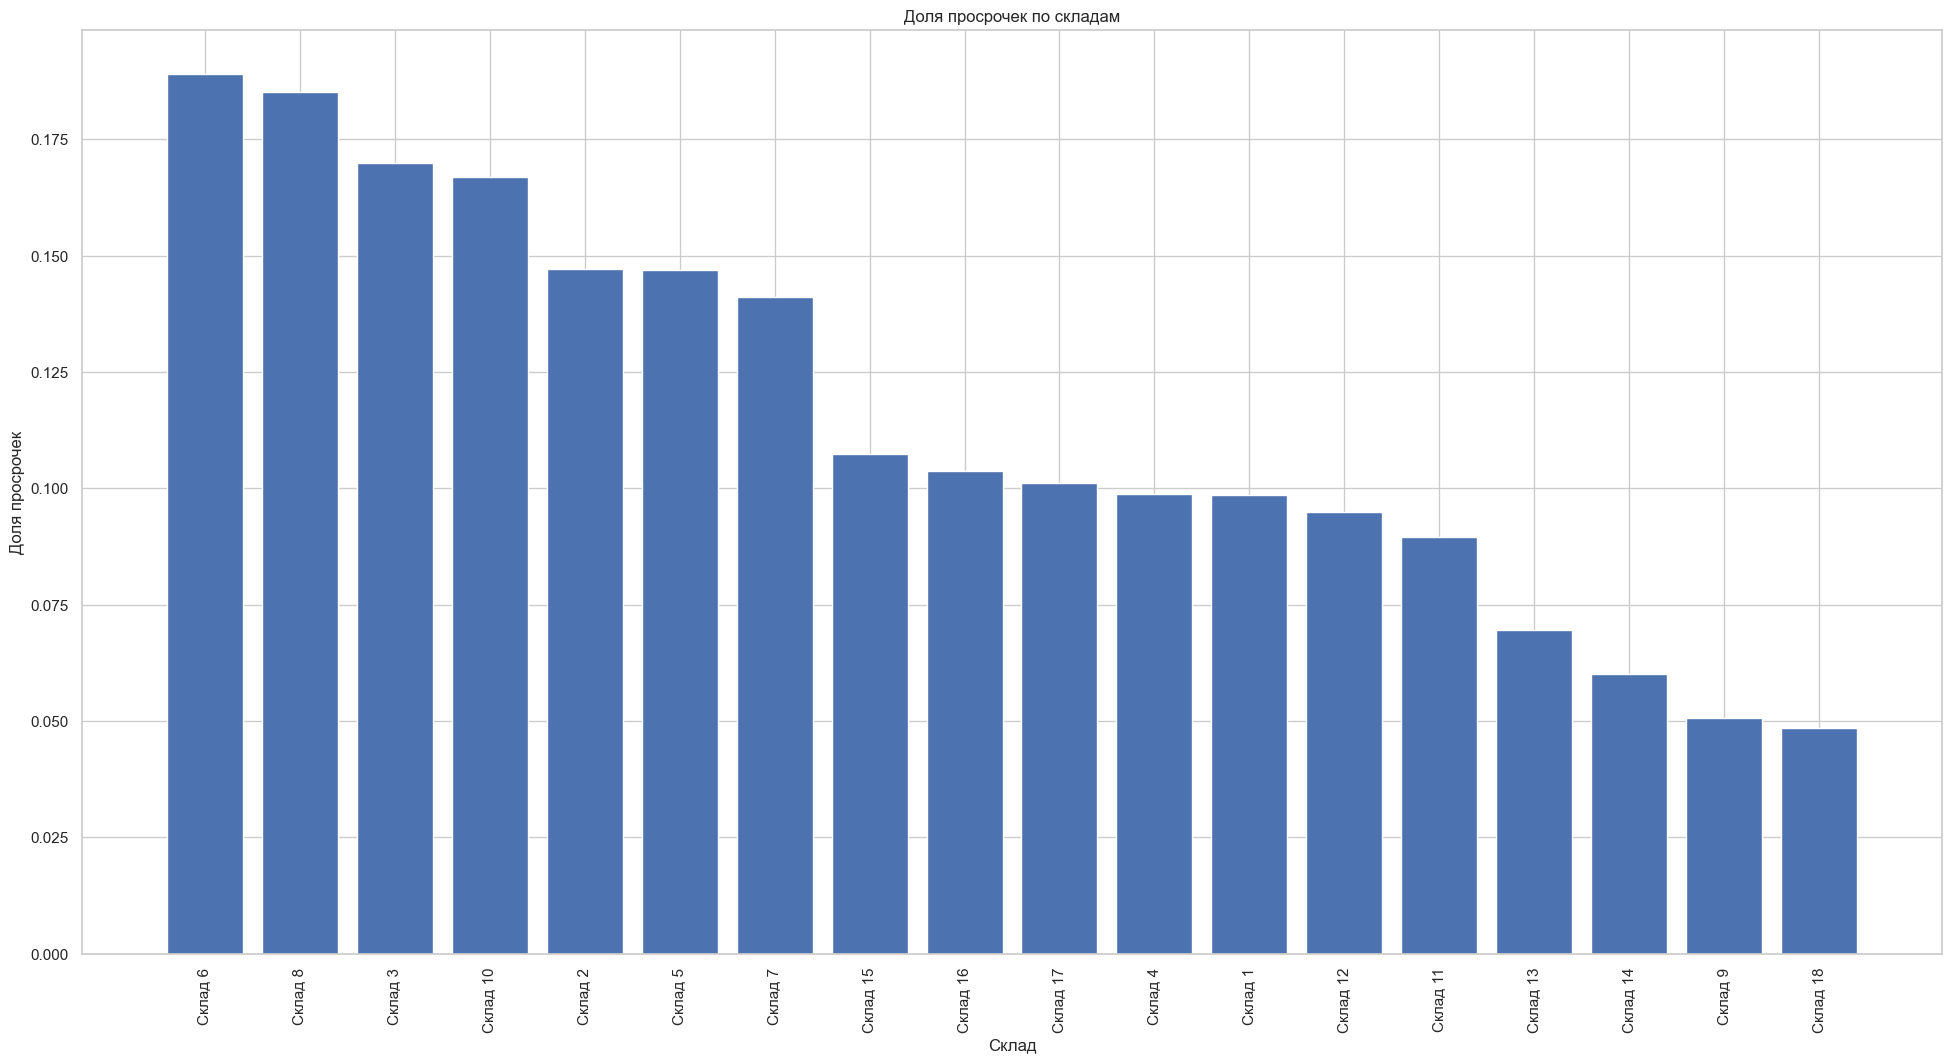

In [14]:
plt.figure(figsize=(24,12))

plt.bar(store_stats["ДаркСтор"], store_stats["late_rate"])

plt.title("Доля просрочек по складам")
plt.xlabel("Склад")
plt.ylabel("Доля просрочек")

plt.xticks(rotation=90)

plt.show()

На графике видно,что  доля просрочек существенно различается между складами.Склад 6 и Склад 8 демонстрируют наибольшую долю просрочек — около 18–19%18–19%, в то время как Склад 9 и 18 значительног меньшую - около 5%.
Разница между худшими и лучими складами более чем в 3 раза говорит о неравномерности эффективности работы складов.
Такая разница может указывать на различия в:
загрузке складов,
скорости сборки,
количестве курьеров в зоне склада,
расстоянии доставки



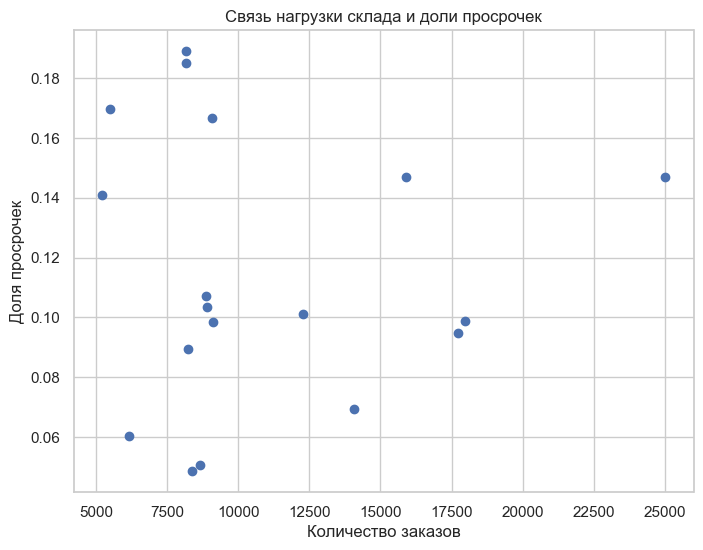

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(store_stats["orders"], store_stats["late_rate"])

plt.title("Связь нагрузки склада и доли просрочек")
plt.xlabel("Количество заказов")
plt.ylabel("Доля просрочек")

plt.show()

На графике показана зависимость между количеством заказов на складе и долей просрочек, из которой следует,что сновная причина задержек была связана не только с перегрузкой складов,так как на графике нет вной линейной зависимости между количеством заказов и долей просрочек.
Некоторые склады с относительно небольшой нагрузкой показывают высокую долю просрочек, в то время как отдельные склады с большим количеством заказов демонстрируют более стабильные показатели.



Просрочка по складам в разные часы

In [16]:
query = """
SELECT
"ДаркСтор",
"Час заказа",
AVG("Заказ просрочен по общему регламентному времени заказа") as late_rate
FROM orders
GROUP BY "ДаркСтор", "Час заказа"
"""

store_hour = pd.read_sql(query, conn)
store_hour.head()

,ДаркСтор,Час заказа,late_rate
0,Склад 1,0,0.073359
1,Склад 1,1,0.108108
2,Склад 1,2,0.022222
3,Склад 1,3,0.057143
4,Склад 1,4,0.076923


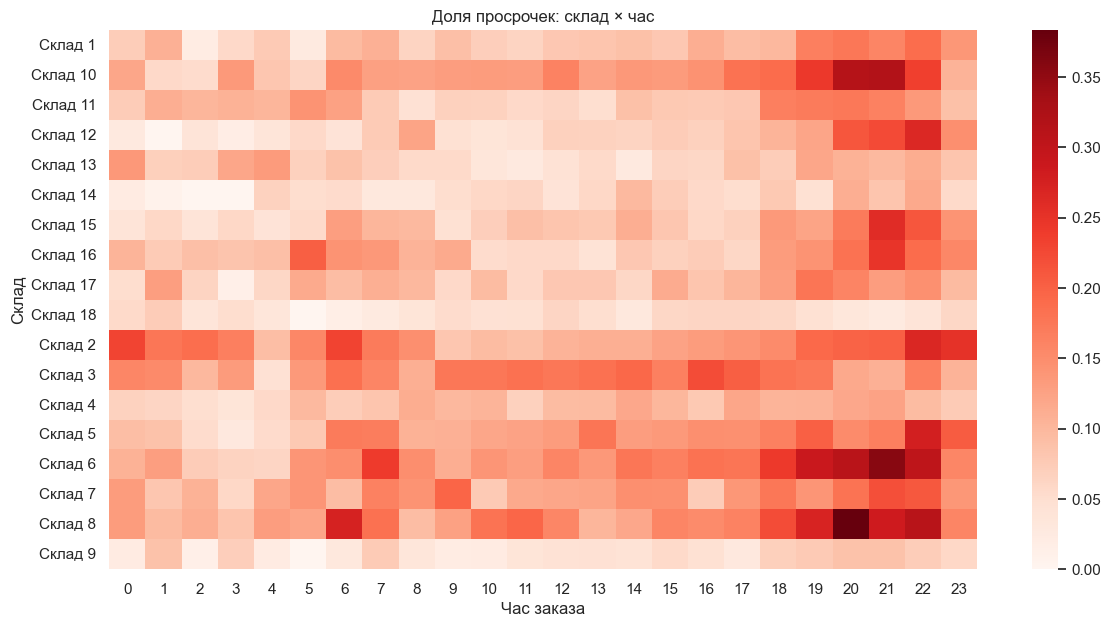

In [17]:
pivot = store_hour.pivot(
    index="ДаркСтор",
    columns="Час заказа",
    values="late_rate"
)

plt.figure(figsize=(14,7))

sns.heatmap(pivot, cmap="Reds")

plt.title("Доля просрочек: склад × час")
plt.xlabel("Час заказа")
plt.ylabel("Склад")

plt.show()

Тепловая карта позволяет уточнить поведение складов, которые ранее были выявлены как аутсайдеры по доле просрочек.

Мы уже выяснили, что наибольшая доля просрочек наблюдается у Склада 6 и Склада 8 . Анализ распределения по часам показывает, что высокий уровень просрочек у этих складов неравномерно распределён в течение дня

Склад 8 демонстрирует особенно высокий уровень просрочек в вечерние часы, где значения достигают максимума среди всех складов.
Склад 6 также показывает заметный рост просрочек во второй половине дня. 
Из этого можно прийти к выводу,что просрочки возникают из-за проблем, возникающих с маштабированием количеством заказов. На карте можно увидеть,что другие склады не показывают такого резкого изменения.
Это позволяет предположить, что высокая доля просрочек у отдельных складов может иметь разные ключевые причины:
для части складов проблема проявляется преимущественно в часы высокой нагрузки,
для других складов задержки могут быть связаны с постоянными операционными ограничениями. И следовательно,они могут требовать разных решений:
для складов(Например,6 и 8) с вечерними пиками — увелечение количество курьеров или перераспределение заказов в часы высокой нагрузки для складов,а
для складов со стабильно высоким уровнем просрочек(Например,10 и 3) — оптимизация процессов сборки или логистики доставки.



##АНАЛИЗ ПО КУРЬЕРАМ


In [18]:
##Количество курьеров по складам
query = """
SELECT
"ДаркСтор",
COUNT(DISTINCT "Курьер") as couriers,
COUNT(*) as orders
FROM orders
GROUP BY "ДаркСтор"
ORDER BY orders DESC
"""

store_couriers = pd.read_sql(query, conn)
store_couriers

,ДаркСтор,couriers,orders
0,Склад 5,150,25010
1,Склад 4,107,17974
2,Склад 12,63,17738
3,Склад 2,87,15896
4,Склад 13,104,14075
5,Склад 17,70,12277
6,Склад 1,70,9121
7,Склад 10,47,9069
8,Склад 16,58,8917
9,Склад 15,43,8875


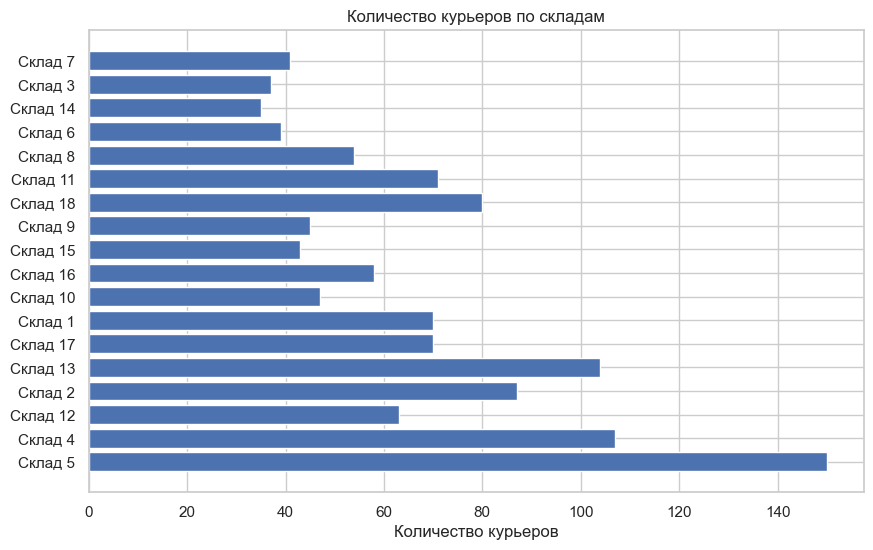

In [19]:
plt.figure(figsize=(10,6))

plt.barh(store_couriers["ДаркСтор"], store_couriers["couriers"])

plt.title("Количество курьеров по складам")
plt.xlabel("Количество курьеров")

plt.show()

In [20]:
##Заказ нат одного курьера
store_couriers["orders_per_courier"] = (
    store_couriers["orders"] / store_couriers["couriers"]
)

store_couriers

,ДаркСтор,couriers,orders,orders_per_courier
0,Склад 5,150,25010,166.733333
1,Склад 4,107,17974,167.981308
2,Склад 12,63,17738,281.555556
3,Склад 2,87,15896,182.712644
4,Склад 13,104,14075,135.336538
5,Склад 17,70,12277,175.385714
6,Склад 1,70,9121,130.300000
7,Склад 10,47,9069,192.957447
8,Склад 16,58,8917,153.741379
9,Склад 15,43,8875,206.395349


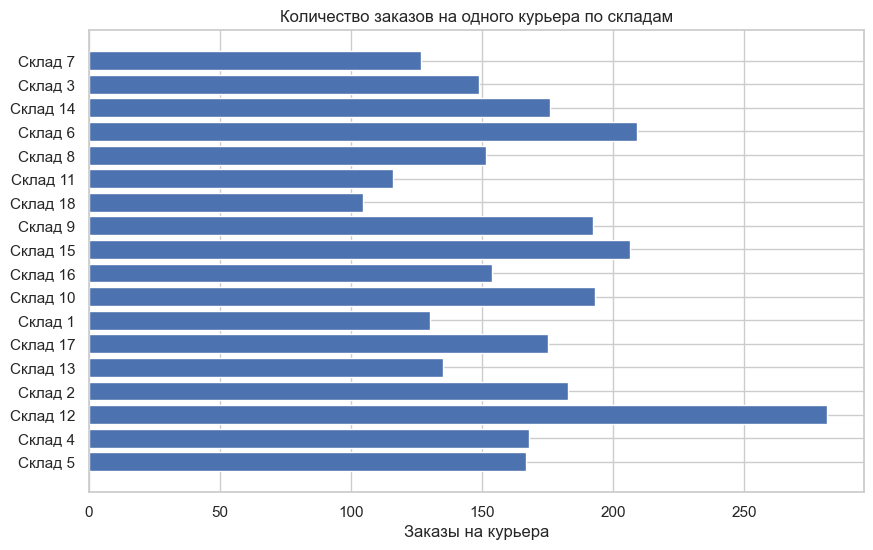

In [21]:
plt.figure(figsize=(10,6))

plt.barh(store_couriers["ДаркСтор"], store_couriers["orders_per_courier"])

plt.title("Количество заказов на одного курьера по складам")
plt.xlabel("Заказы на курьера")

plt.show()

Из графика видно, что нагрузка на курьеров существенно различается между складами:
Склад 12 демонстрирует одну из самых высоких нагрузок на курьера,
Склад 6 также имеет достаточно высокое количество заказов на одного курьера,
В то же время некоторые склады имеют значительно более низкую нагрузку

После сопоставления этих результатов с предыдущими этапами анализа, можно заметить, что часть складов(), ранее выявленных как проблемные по доле просрочек, также характеризуются повышенной нагрузкой на курьеров, это подверждает также тот факт,что опоздания там не яалюстся контрастными,а остаюся относительно равномерными весь день
            
Это может указывать на то, что для некоторых складов высокая доля просрочек может быть связана с перегрузкой курьеров, когда одному курьеру приходится обслуживать слишком большое количество заказо

##ИТОГОВЫЕ ВЫВОДЫ

В рамках анализа данных по заказам за 7 дней были исследованы основные факторы, влияющие на просрочки доставки: время заказа, распределение нагрузки по складам и курьерам, а также этап сборки заказа.

1. Общий уровень просрочек

Примерно 11.5% заказов доставляются с нарушением регламентного времени. При этом просрочка на этапе сборки составляет около 4.4%, что позволяет предположить, что основная часть задержек возникает на этапе доставки, а не сборки заказа.

2. Влияние времени заказа

Количество заказов существенно возрастает в течение дня и достигает пиковых значений в утренние и вечерние часы. В вечерний период наблюдается рост доли просрочек, что может быть связано с увеличением нагрузки на систему доставки.

3. Различия между складами

Анализ показал значительные различия между складами по доле просрочек.
Некоторые склады (например Склад 6 и Склад 8) демонстрируют заметно более высокий уровень задержек по сравнению с другими.

При этом тепловая карта показала, что рост просрочек на этих складах особенно выражен в часы повышенной нагрузки, что может указывать на проблемы с масштабированием при увеличении количества заказов.


4. Нагрузка на курьеров

Анализ распределения заказов на одного курьера показал, что нагрузка на курьеров существенно различается между складами.

На отдельных складах наблюдается более высокое количество заказов на одного курьера, что может приводить к увеличению времени доставки и росту вероятности просрочек.


5. Общая интерпретация


Проведённый анализ показывает, что проблема просрочек носит комплексный характер и связана в первую очередь с особенностями логистики доставки, включая:
распределение заказов между складами,
доступность курьеров,
рост нагрузки в часы пик.

6.

На основе проведённого анализа можно предложить следующие направления для дальнейшей оптимизации:
увеличение числа курьеров для складов с высокой нагрузкой,
перераспределение заказов между складами,
дополнительный анализ логистики доставки в часы пик,
мониторинг складов с повышенной долей просрочек.

